In [58]:
import numpy as np
from PIL import Image

In [59]:
from pathlib import Path

img_path = Path.cwd().parent.parent / "Images" / "smilingface-2048x2048.jpg"
img = Image.open(img_path).convert("L")

print(type(img))
print(img.size)

<class 'PIL.Image.Image'>
(2048, 1365)


In [60]:
A = np.array(img)
print(type(A))
print(A.shape)

<class 'numpy.ndarray'>
(1365, 2048)


In [61]:
# 2. Perform SVD
U, S, Vt = np.linalg.svd(A, full_matrices=False)

In [62]:
# 3. Reconstruct at Rank k
def reconstruct(k, U, S, Vt):
    # Use only first k components
    Ak = np.matrix(U[:, :k]) * np.diag(S[:k]) * np.matrix(Vt[:k, :])
    return Ak

In [63]:
# Examples
rank_1  = reconstruct(1, U, S, Vt)
rank_50 = reconstruct(50, U, S, Vt)

In [64]:
print(rank_1.shape)
print(rank_50.shape)

(1365, 2048)
(1365, 2048)


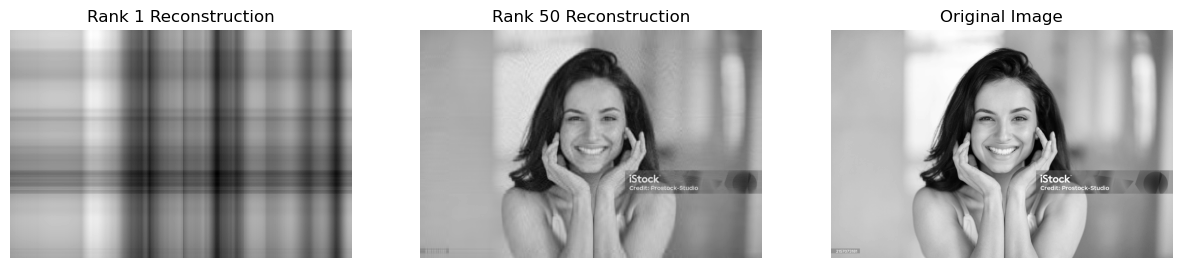

In [66]:
import matplotlib.pyplot as plt

def display_reconstructions(original, r1, r50):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Display Rank 1
    axes[0].imshow(r1, cmap='gray')
    axes[0].set_title('Rank 1 Reconstruction')
    axes[0].axis('off')

    # Display Rank 50
    axes[1].imshow(r50, cmap='gray')
    axes[1].set_title('Rank 50 Reconstruction')
    axes[1].axis('off')

    # Display Original for comparison
    axes[2].imshow(original, cmap='gray')
    axes[2].set_title('Original Image')
    axes[2].axis('off')

    plt.show()

# Calling the function
display_reconstructions(A, rank_1, rank_50)

In [67]:
# Find the mathematical rank
rgb_img = Image.open(img_path)
rgb_img_arr = np.array(rgb_img)
rank = np.linalg.matrix_rank(rgb_img_arr)

# RGB images have shape (Height, Width, 3)
    # We calculate the rank for each channel separately
ranks = {
    "Red":   np.linalg.matrix_rank(rgb_img_arr[:, :, 0]),
    "Green": np.linalg.matrix_rank(rgb_img_arr[:, :, 1]),
    "Blue":  np.linalg.matrix_rank(rgb_img_arr[:, :, 2])
}
print(f"Image Dimensions: {rgb_img_arr.shape}")
print(f"Channel-wise Ranks: {ranks}")

Image Dimensions: (1365, 2048, 3)
Channel-wise Ranks: {'Red': 1365, 'Green': 1365, 'Blue': 1365}


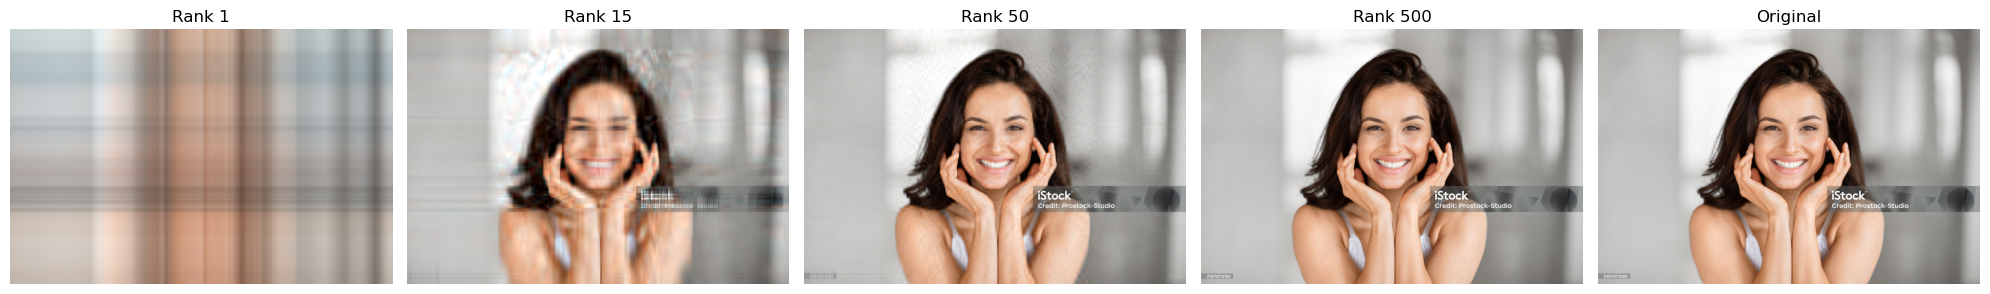

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def compress_rgb_image(image_path, ranks):
    # 1. Load the image
    img = Image.open(image_path)
    # Convert to float for SVD math
    A = np.array(img, dtype=float) 
    
    # Get dimensions (e.g., 1000, 800, 3)
    height, width, channels = A.shape
    
    # 2. Perform SVD on each channel separately
    # Results are stored in lists for R, G, and B
    svd_data = [np.linalg.svd(A[:, :, i], full_matrices=False) for i in range(channels)]
    
    # Setup the plot
    fig, axes = plt.subplots(1, len(ranks) + 1, figsize=(20, 5))
    
    # 3. Process each requested rank
    for idx, k in enumerate(ranks):
        # Create an empty container for the reconstructed RGB image
        reconstructed_img = np.zeros_like(A)
        
        for i in range(channels):
            U, S, Vt = svd_data[i]
            # Construct rank-k approximation for the current channel
            # Formula: Ak = U[:, :k] * diag(S[:k]) * Vt[:k, :]
            Ak = np.dot(U[:, :k] * S[:k], Vt[:k, :])
            reconstructed_img[:, :, i] = Ak
            
        # 4. Post-processing: Clip values to [0, 255] and convert to uint8
        reconstructed_img = np.clip(reconstructed_img, 0, 255).astype(np.uint8)
        
        axes[idx].imshow(reconstructed_img)
        axes[idx].set_title(f'Rank {k}')
        axes[idx].axis('off')
        
    # Show original for comparison
    axes[-1].imshow(A.astype(np.uint8))
    axes[-1].set_title('Original')
    axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the function
# Note: Ensure rank 500 isn't larger than your image width/height

compress_rgb_image(img_path, [1, 15, 50, 500])

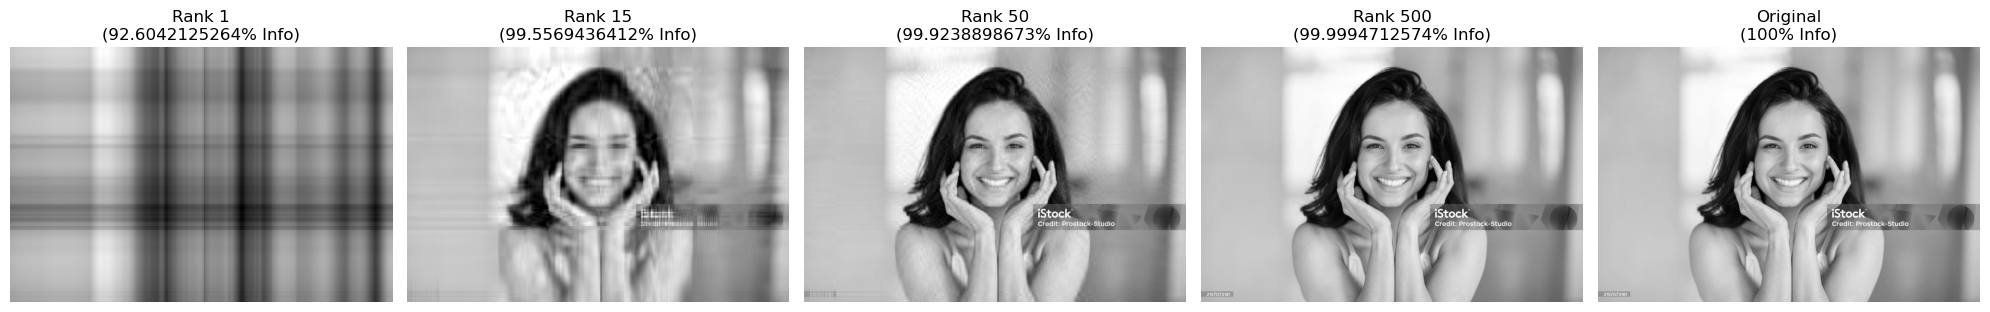

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def compress_grayscale_image(image_path, ranks):
    # 1. Load image and convert to Grayscale ('L' mode)
    img = Image.open(image_path).convert('L')
    A = np.array(img, dtype=float)
    
    # 2. Perform SVD
    # full_matrices=False gives us the economy size (Reduced SVD)
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    
    # Calculate total variance (energy) for information percentage
    total_energy = np.sum(S**2)
    
    # Setup plotting
    fig, axes = plt.subplots(1, len(ranks) + 1, figsize=(20, 5))
    
    # 3. Process each rank
    for idx, k in enumerate(ranks):
        # Ensure k doesn't exceed the actual max rank
        k = min(k, len(S))
        
        # Reconstruct: Ak = U_k * S_k * Vt_k
        # Optimization: Multiply U with S first, then dot with Vt
        Ak = np.dot(U[:, :k] * S[:k], Vt[:k, :])
        
        # Calculate how much "energy" (information) we kept
        retained_energy = np.sum(S[:k]**2)
        variance_pct = (retained_energy / total_energy) * 100
        
        # Post-process for display
        Ak_display = np.clip(Ak, 0, 255).astype(np.uint8)
        
        axes[idx].imshow(Ak_display, cmap='gray')
        axes[idx].set_title(f'Rank {k}\n({variance_pct:.10f}% Info)')
        axes[idx].axis('off')
        
    # Show original
    axes[-1].imshow(A.astype(np.uint8), cmap='gray')
    axes[-1].set_title('Original\n(100% Info)')
    axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run for your specific ranks
compress_grayscale_image(img_path, [1, 15, 50, 500])